In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
# --- 1.1 加载数据 ---
file_path = './ancient_bert_embedding_data/MASK_encoder_layer11.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"错误：找不到文件 '{file_path}'。请检查文件名和路径是否正确。")
    exit()

# 分离标签和数值数据
## 第一列是关系标签
labels = df.iloc[:, 0].values
## 其余列是768维的嵌入向量
embedding_data = df.iloc[:, 1:].values

print(f"数据加载成功！共 {len(labels)} 个关系，每个关系有 {embedding_data.shape[1]} 个维度。")

# --- 1.2 数据标准化 ---
## 创建一个标准化处理器
scaler = StandardScaler()
## 对数据进行标准化 (使其均值为0，方差为1)
scaled_data = scaler.fit_transform(embedding_data)

print("数据标准化完成。")

数据加载成功！共 18 个关系，每个关系有 768 个维度。
数据标准化完成。


d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37322 (\N{CJK UNIFIED IDEOGRAPH-91CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site

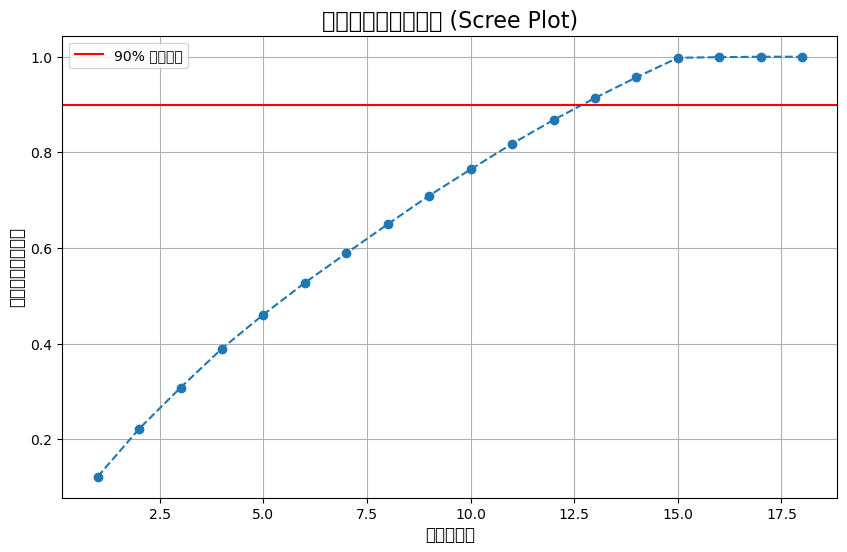

前20个主成分的解释方差贡献率:
  PC-1: 12.18%
  PC-2: 10.01%
  PC-3: 8.62%
  PC-4: 8.17%
  PC-5: 7.10%
  PC-6: 6.65%
  PC-7: 6.16%
  PC-8: 6.08%
  PC-9: 5.96%
  PC-10: 5.50%
  PC-11: 5.35%
  PC-12: 4.97%
  PC-13: 4.60%
  PC-14: 4.31%
  PC-15: 4.09%
  PC-16: 0.14%
  PC-17: 0.09%
  PC-18: 0.00%


In [4]:
# --- 2.1 运行一个完整的PCA来评估所有成分 ---
pca_full = PCA()
pca_full.fit(scaled_data)

# --- 2.2 计算并可视化累积解释方差 ---
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# 绘制碎石图
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('累积解释方差贡献率 (Scree Plot)', fontsize=16)
plt.xlabel('主成分数量', fontsize=12)
plt.ylabel('累积解释方差比例', fontsize=12)
plt.grid(True)
# 加上参考线，比如90%的方差阈值
plt.axhline(y=0.90, color='r', linestyle='-', label='90% 解释方差')
plt.legend(loc='best')
plt.show()

# 打印出前几个成分的解释度
print("前20个主成分的解释方差贡献率:")
for i, ratio in enumerate(explained_variance_ratio[:20]):
    print(f"  PC-{i+1}: {ratio*100:.2f}%")




PCA降维后的数据预览:
  relationship        PC1        PC2        PC3        PC4        PC5  \
0        家主-嫡妻  22.758789 -10.520324   2.513309  -1.896880  -0.064473   
1         家主-妾   1.676646   7.051175  -2.933142  -2.269849  10.567362   
2         夫-原配  -6.602030  -4.294250 -13.375015  -7.196882 -14.670476   
3         夫-续弦 -11.823703 -16.956934   4.423735  10.233029   5.312875   
4        原配-继室  22.918688 -10.351467   2.450258  -2.264716   0.020414   

         PC6       PC7       PC8       PC9      PC10      PC11      PC12  \
0  -0.937777  2.698436 -0.743858 -0.395327 -2.775602 -4.235250  0.195367   
1  14.087264  6.235518 -3.983616 -0.729746  8.383759 -2.414841 -5.918320   
2  17.382727  1.033087  2.615599  2.958750 -8.307051 -0.775955  0.193075   
3   2.275716 -1.333249  0.865782 -0.446701 -2.074738  1.234784 -0.617474   
4  -0.904884  2.611553 -0.833838 -0.324646 -2.923021 -4.188229  0.375968   

       PC13      PC14       PC15  
0 -0.932007  0.390422  -0.380968  
1  2.967422  1.45197

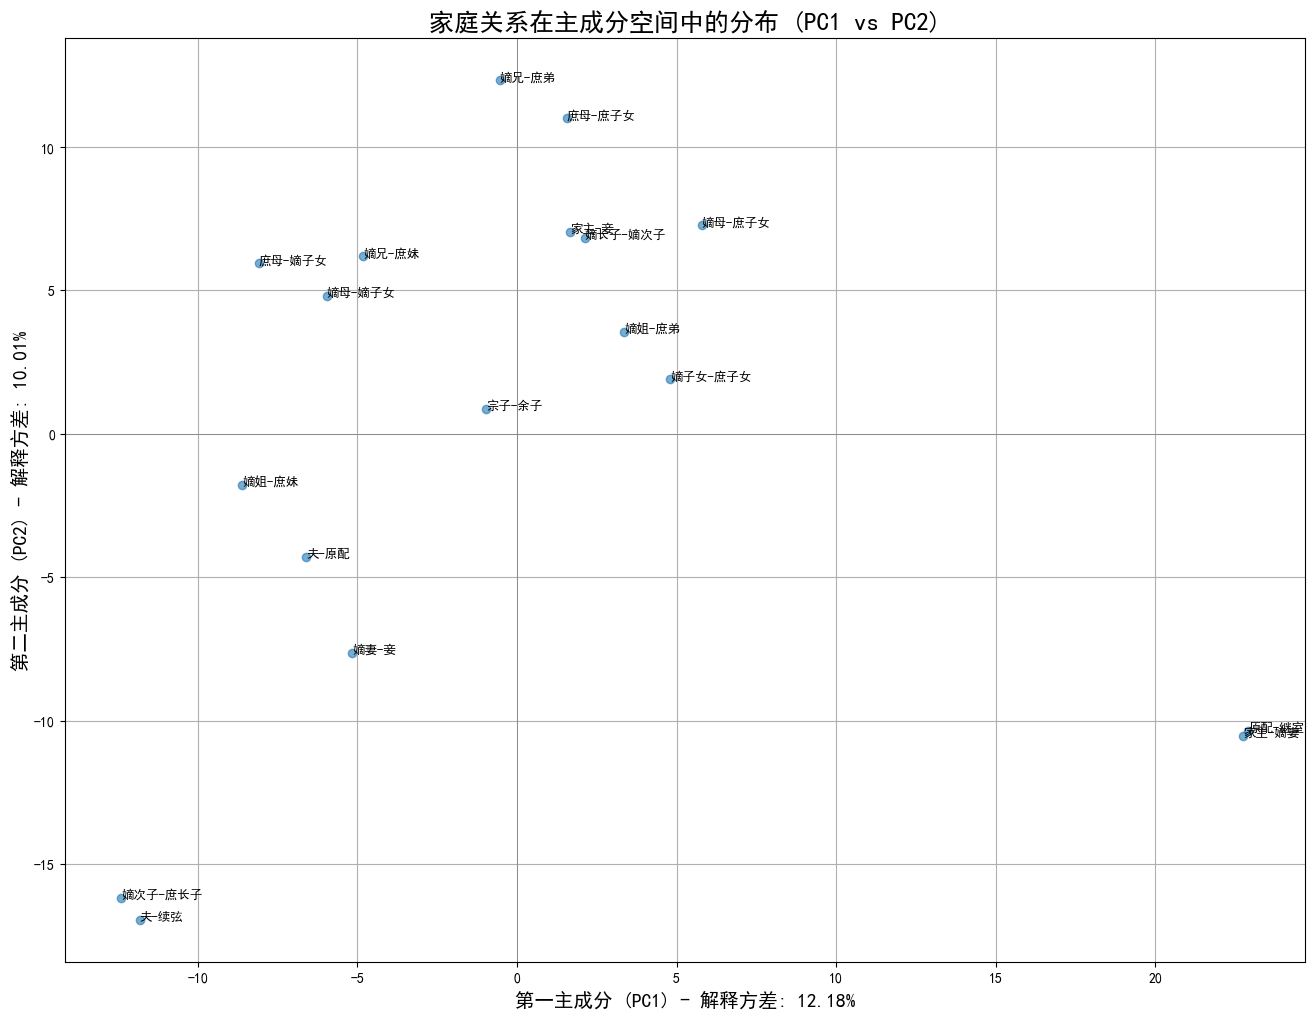

In [5]:
# --- 3.1 确定主成分数量 ---
N_COMPONENTS = 15

# --- 3.2 执行最终的PCA ---
pca_final = PCA(n_components=N_COMPONENTS)
principal_components = pca_final.fit_transform(scaled_data)

# 将结果存入一个新的DataFrame，方便后续分析
pc_df = pd.DataFrame(data=principal_components, 
                     columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])
pc_df.insert(0, 'relationship', labels)

print("\nPCA降维后的数据预览:")
print(pc_df.head())


# --- 3.3 可视化PC1与PC2 ---
# 为了在图上正确显示中文，我们需要设置字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是常用的黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

plt.figure(figsize=(16, 12))
pc1_scores = pc_df['PC1']
pc2_scores = pc_df['PC2']

plt.scatter(pc1_scores, pc2_scores, alpha=0.6)

# 在每个点旁边添加关系标签
for i, label in enumerate(pc_df['relationship']):
    plt.text(pc1_scores[i], pc2_scores[i], label, fontsize=9)

plt.title('家庭关系在主成分空间中的分布 (PC1 vs PC2)', fontsize=18)
plt.xlabel(f'第一主成分 (PC1) - 解释方差: {pca_final.explained_variance_ratio_[0]*100:.2f}%', fontsize=14)
plt.ylabel(f'第二主成分 (PC2) - 解释方差: {pca_final.explained_variance_ratio_[1]*100:.2f}%', fontsize=14)
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.show()

In [6]:
# --- 4.1 解读第一主成分 (PC1) ---
pc1_sorted = pc_df.sort_values(by='PC1', ascending=False)

print("\n--- 解读PC1 ---")
print("PC1得分最高的5个关系 (PC1正半轴):")
print(pc1_sorted[['relationship', 'PC1']].head(5))
print("\nPC1得分最低的5个关系 (PC1负半轴):")
print(pc1_sorted[['relationship', 'PC1']].tail(5))

# --- 4.2 解读第二主成分 (PC2) ---
pc2_sorted = pc_df.sort_values(by='PC2', ascending=False)

print("\n--- 解读PC2 ---")
print("PC2得分最高的5个关系 (PC2正半轴):")
print(pc2_sorted[['relationship', 'PC2']].head(5))
print("\nPC2得分最低的5个关系 (PC2负半轴):")
print(pc2_sorted[['relationship', 'PC2']].tail(5))


--- 解读PC1 ---
PC1得分最高的5个关系 (PC1正半轴):
   relationship        PC1
4         原配-继室  22.918688
0         家主-嫡妻  22.758789
7        嫡母-庶子女   5.791005
11      嫡子女-庶子女   4.806817
16        嫡姐-庶弟   3.353953

PC1得分最低的5个关系 (PC1负半轴):
   relationship        PC1
2          夫-原配  -6.602030
8        庶母-嫡子女  -8.093729
17        嫡姐-庶妹  -8.616715
3          夫-续弦 -11.823703
13      嫡次子-庶长子 -12.398444

--- 解读PC2 ---
PC2得分最高的5个关系 (PC2正半轴):
   relationship        PC2
14        嫡兄-庶弟  12.332805
9        庶母-庶子女  10.996674
7        嫡母-庶子女   7.268376
1          家主-妾   7.051175
12      嫡长子-嫡次子   6.839339

PC2得分最低的5个关系 (PC2负半轴):
   relationship        PC2
5          嫡妻-妾  -7.641506
4         原配-继室 -10.351467
0         家主-嫡妻 -10.520324
13      嫡次子-庶长子 -16.177450
3          夫-续弦 -16.956934
